# Assignemt 01 - Sentiment Analysis

<details>
  <summary><span style="font-size:1.5em; font-weight:bold; color:#1f77b4;">Problem Statement</span></summary>

  <p>

### Sentiment Analysis Using TF-IDF Vectors

**Objective:**  
Design and implement a machine learning model to perform sentiment analysis on a given dataset containing textual data and corresponding sentiment labels. The analysis should use **TF-IDF (Term Frequency-Inverse Document Frequency)** vectors to transform the text into numerical features and classify the sentiments effectively.

### Dataset Description for Sentiment Analysis Project

**Content:**  
The dataset is stored in a **CSV file** and includes six fields:

1. **Polarity (Column 0):**  
   - Sentiment label for the tweet:  
     - `0`: Negative sentiment  
     - `2`: Neutral sentiment  
     - `4`: Positive sentiment

2. **Tweet ID (Column 1):**  
   - A unique identifier for each tweet.

3. **Date (Column 2):**  
   - The timestamp of when the tweet was posted, in the format:  
     `Day Month Date HH:MM:SS UTC Year`  
     *(e.g., Sat May 16 23:58:44 UTC 2009)*

4. **Query (Column 3):**  
   - The search query used to retrieve the tweet.  
     If no query was used, the value is `NO_QUERY`.

5. **User (Column 4):**  
   - The username of the account that posted the tweet  
     *(e.g., robotickilldozr)*

6. **Text (Column 5):**  
   - The content of the tweet, consisting of raw text after emoticons have been removed  
     *(e.g., Lyx is cool)*

Dataset Source on Kaggle
  </p>
</details>

## To Do List

- [ ] Clean the better the text before doing the training. remove stop words, lemmatize etc...
- [ ] Keep the ANN simple.

## Imports

In [1]:
# import kagglehub
import pandas as pd
import html
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Download NLTK resources if needed
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('tokenizers/punkt_tab')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('punkt_tab')
    nltk.download('stopwords')
    nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\raad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\raad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\raad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\raad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Read + EDA

In [3]:
train_df = pd.read_csv("../Data/train.csv", encoding="Windows-1252")
test_df = pd.read_csv("../Data/test.csv", encoding="Windows-1252")

In [4]:
train_df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [5]:
test_df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


focus only on necessary info

In [6]:
train_df = train_df[["text", "sentiment"]]
test_df = test_df[["text", "sentiment"]]

print(f"train has {len(train_df)} rows, and test has {len(test_df)} rows.")

train has 27481 rows, and test has 4815 rows.


check for Nans

In [7]:
print("train Nans")
print(train_df.isnull().sum())
print("test Nans")
print(test_df.isnull().sum())

train Nans
text         1
sentiment    0
dtype: int64
test Nans
text         1281
sentiment    1281
dtype: int64


In [8]:
before = len(train_df)
train_df.dropna(how="any", inplace=True)
print(f"{before - len(train_df)} NaN rows dropped.")
before = len(test_df)
test_df.dropna(how="any", inplace=True)
print(f"{before - len(test_df)} NaN rows dropped.")

1 NaN rows dropped.
1281 NaN rows dropped.


do basic text cleaning

In [9]:
def basic_text_clean(text):
    text = html.unescape(text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower()
    text = text.strip()
    return text

In [10]:
train_df["text"] = train_df["text"].apply(basic_text_clean)
test_df["text"] = test_df["text"].apply(basic_text_clean)

check for duplicates

In [11]:
has_duplicates = train_df.duplicated().any()
print("train_df has duplicates:", has_duplicates)
has_duplicates = test_df.duplicated().any()
print("test_df has duplicates:", has_duplicates)

train_df has duplicates:

 True
test_df has duplicates: True


clean duplicates after clean text ... leads to more rows dropped

In [12]:
before = len(train_df)
train_df.drop_duplicates(inplace=True)
print(f"{before - len(train_df)} rows are dropped")
before = len(test_df)
test_df.drop_duplicates(inplace=True)
print(f"{before - len(test_df)} rows are dropped")

68 rows are dropped
5 rows are dropped


In [13]:
print(f"train has {len(train_df)} rows, and test has {len(test_df)} rows.")

train has 27412 rows, and test has 3529 rows.


polarity here is a text we will change it to 0 2 4

In [14]:
sentiment_mapping = {'negative': 0, 'neutral': 2, 'positive': 4}

In [15]:
train_df["polarity"] = train_df["sentiment"].map(sentiment_mapping)
test_df["polarity"] = test_df["sentiment"].map(sentiment_mapping)


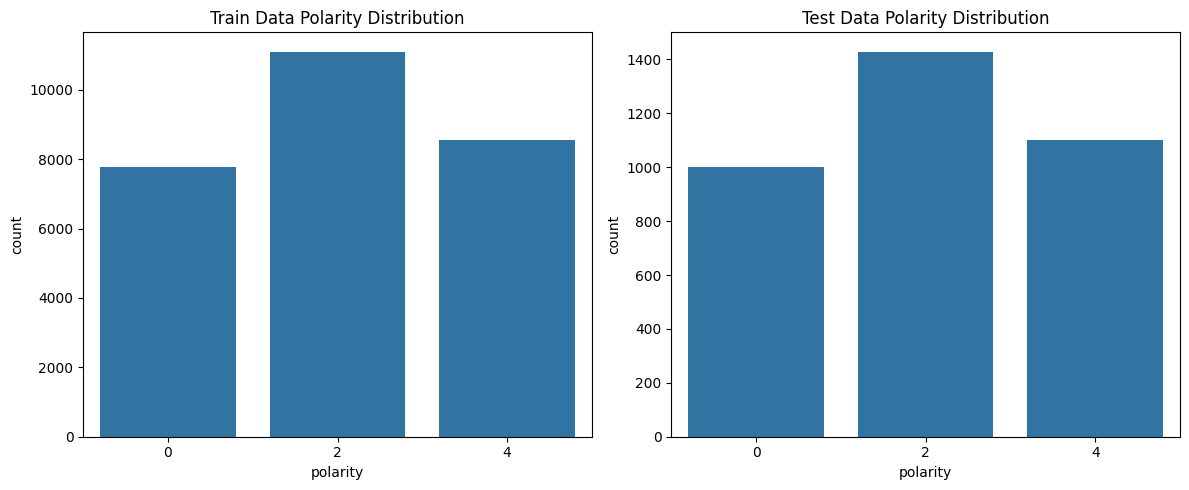

In [16]:
# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train data polarity distribution
sns.countplot(data=train_df, x="polarity", ax=axes[0])
axes[0].set_title("Train Data Polarity Distribution")

# Test data polarity distribution
sns.countplot(data=test_df, x="polarity", ax=axes[1])
axes[1].set_title("Test Data Polarity Distribution")

plt.tight_layout()

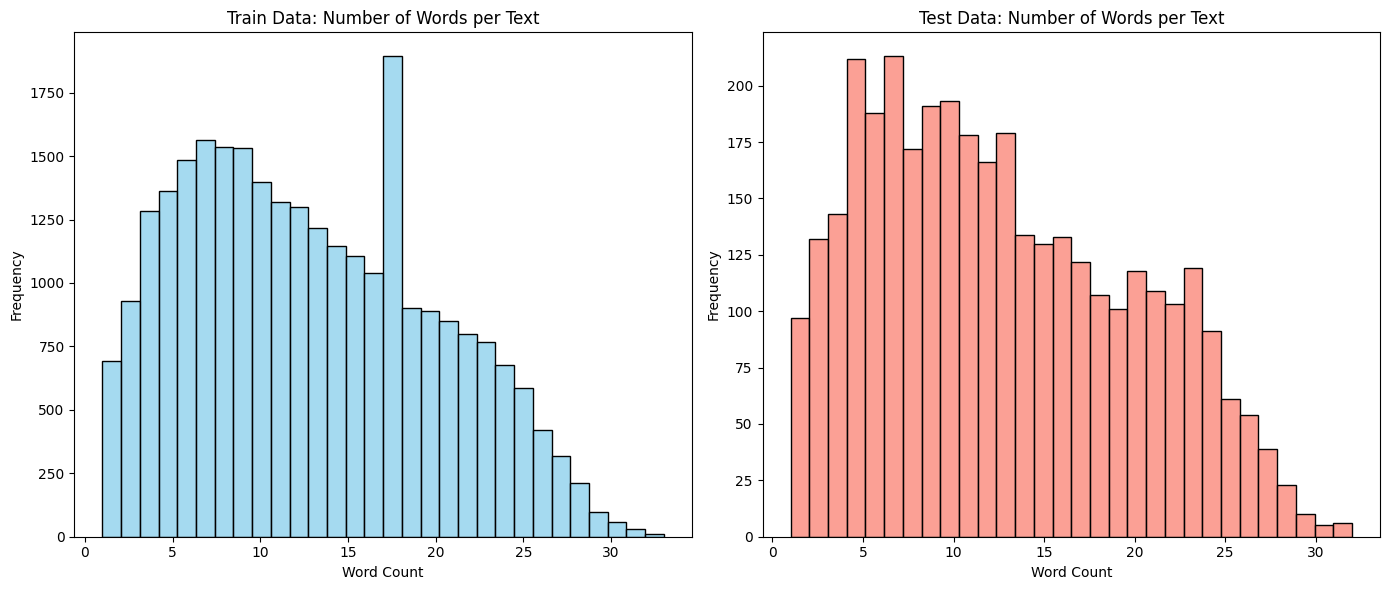

In [17]:
# Calculate word counts
train_word_counts = train_df['text'].astype(str).apply(lambda x: len(x.split()))
test_word_counts = test_df['text'].astype(str).apply(lambda x: len(x.split()))

# Create side-by-side histograms with separate y-axis scales
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(train_word_counts, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Train Data: Number of Words per Text')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

sns.histplot(test_word_counts, bins=30, ax=axes[1], color='salmon')
axes[1].set_title('Test Data: Number of Words per Text')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()

## TF-IDF

In [18]:
import string 

def text_preprocess(text):
    # Remove urls
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove hashtags (keeping the text after #)
    text = re.sub(r'#(\w+)', r'\1', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    # Join tokens back into text
    text = ' '.join(tokens)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation)).strip()
    return text

In [19]:
train_df["text"] = train_df["text"].apply(text_preprocess)
test_df["text"] = test_df["text"].apply(text_preprocess)

In [105]:
tfidf_ngram_vectorizer = TfidfVectorizer(ngram_range=(2, 4), max_features=2048)
tfidf_ngram_vectorizer_train = tfidf_ngram_vectorizer.fit_transform(train_df["text"])
tfidf_ngram_vectorizer_test = tfidf_ngram_vectorizer.transform(test_df["text"])
tfidf_ngram_vectorizer.get_feature_names_out()[150:160]

array(['coming soon', 'coming tomorrow', 'concert tonight', 'cool movie',
       'cool people', 'cost much', 'could afford', 'could come',
       'could done', 'could find'], dtype=object)

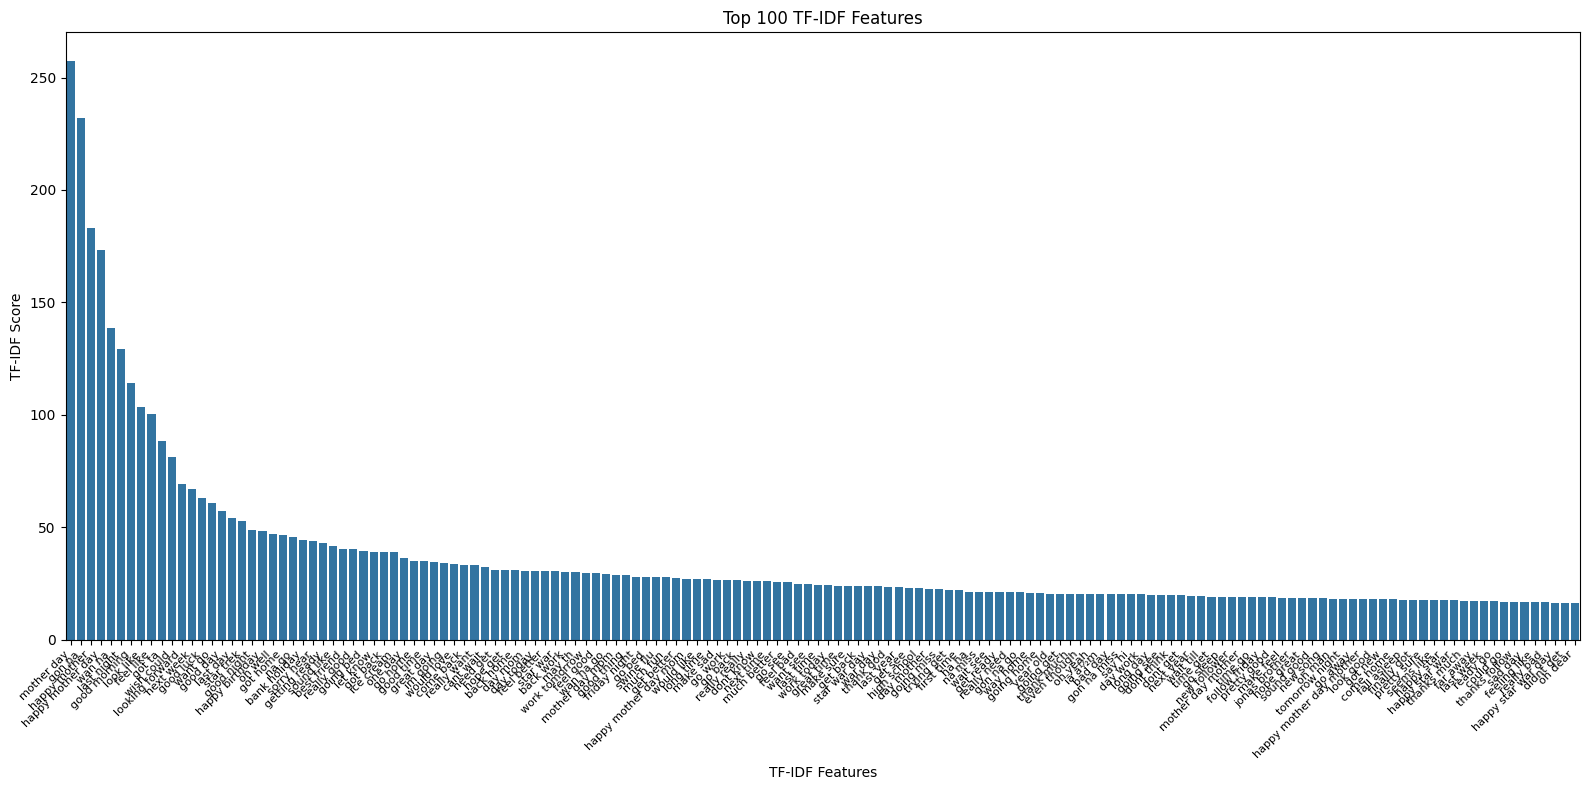

In [106]:

# Get feature names and summed TF-IDF values
feature_array = tfidf_ngram_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_ngram_vectorizer_train.sum(axis=0).A1
tfidf_freq_df = pd.DataFrame({'feature': feature_array, 'tfidf_sum': tfidf_scores})


feature_scores = pd.DataFrame({'feature': feature_array, 'score': tfidf_scores})

# Get top 100 features by score
top_features = feature_scores.nlargest(150, 'score')

# Plot using seaborn with flipped axes and rotated x-axis labels
plt.figure(figsize=(16, 8))
sns.barplot(data=top_features, x='feature', y='score')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.xlabel("TF-IDF Features")
plt.ylabel("TF-IDF Score")
plt.title("Top 100 TF-IDF Features")
plt.tight_layout()
plt.savefig("top_100_tfidf_features_flipped.png")
plt.show()



In [107]:
train_vectors = tfidf_ngram_vectorizer_train.toarray()
print(train_vectors.shape)
test_vectors = tfidf_ngram_vectorizer_test.toarray()
print(test_vectors.shape)

(27412, 2048)
(3529, 2048)


In [108]:
# converting the features_train and features_validation 
train_vectors = torch.tensor(train_vectors, dtype=torch.float32)
test_vectors = torch.tensor(test_vectors, dtype=torch.float32)

## Model + Training + Eval

In [109]:
train_vectors.shape

torch.Size([27412, 2048])

In [110]:
# convert target variables into pytorch tensors
label_map = {0: 0, 2: 1, 4: 2}

y_train = torch.tensor(train_df["polarity"].map(label_map).to_numpy(), dtype=torch.long)
y_test = torch.tensor(test_df["polarity"].map(label_map).to_numpy(), dtype=torch.long)

In [111]:
y_train.shape
y_test.shape

torch.Size([3529])

In [112]:
# initialise TensorDataset  object
train_dataset = TensorDataset(train_vectors, y_train)
val_dataset = TensorDataset(test_vectors, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=True)

In [113]:
class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size=8, output_size=3, dropout_rate=0.43):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, output_size)
        # No activation here; use CrossEntropyLoss during training

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out  # raw logits

In [114]:
model = ANNModel(input_size=train_vectors.shape[1])

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [115]:
num_epochs = 30  # Number of epochs
losses = []  # List to store the average loss per epoch
val_losses = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0  # Variable to store the total loss in each epoch
    total_val_loss = 0
    count = 0  # Variable to count the number of batches
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count  # Calculate average loss for the epoch
    losses.append(average_loss)  # Append average loss to the list
       
    for inputs, labels in val_loader:
        val_outputs = model(inputs)
        val_outputs = val_outputs
        val_loss = criterion(val_outputs, labels)
        total_val_loss += val_loss.item()
        val_count += 1
    average_val_loss = total_val_loss / val_count  # Calculate average loss for the epoch
    val_losses.append(average_val_loss)  # Append average loss to the list
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')

Epoch 1/30, Loss: 1.1154, Val Loss: 1.0980
Epoch 2/30, Loss: 1.0835, Val Loss: 1.0729
Epoch 3/30, Loss: 1.0581, Val Loss: 1.0537
Epoch 4/30, Loss: 1.0379, Val Loss: 1.0416
Epoch 5/30, Loss: 1.0204, Val Loss: 1.0320
Epoch 6/30, Loss: 1.0043, Val Loss: 1.0284
Epoch 7/30, Loss: 0.9940, Val Loss: 1.0228
Epoch 8/30, Loss: 0.9863, Val Loss: 1.0243
Epoch 9/30, Loss: 0.9831, Val Loss: 1.0205
Epoch 10/30, Loss: 0.9731, Val Loss: 1.0124
Epoch 11/30, Loss: 0.9677, Val Loss: 1.0185
Epoch 12/30, Loss: 0.9668, Val Loss: 1.0152
Epoch 13/30, Loss: 0.9594, Val Loss: 1.0137
Epoch 14/30, Loss: 0.9578, Val Loss: 1.0163
Epoch 15/30, Loss: 0.9584, Val Loss: 1.0179
Epoch 16/30, Loss: 0.9529, Val Loss: 1.0135
Epoch 17/30, Loss: 0.9492, Val Loss: 1.0248
Epoch 18/30, Loss: 0.9416, Val Loss: 1.0226
Epoch 19/30, Loss: 0.9454, Val Loss: 1.0222
Epoch 20/30, Loss: 0.9416, Val Loss: 1.0143
Epoch 21/30, Loss: 0.9379, Val Loss: 1.0266
Epoch 22/30, Loss: 0.9370, Val Loss: 1.0181
Epoch 23/30, Loss: 0.9360, Val Loss: 1.02

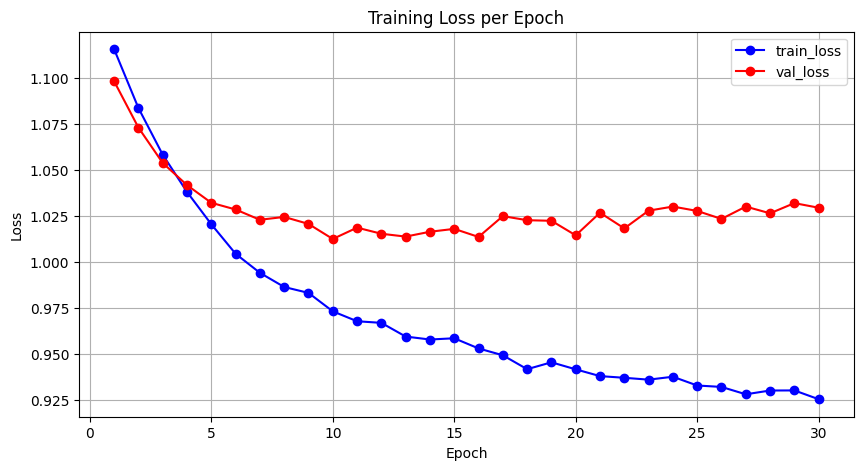

In [116]:
# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-', color='b', label = 'train_loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', linestyle='-', color='r', label = 'val_loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [117]:
def calculate_accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)  # shape: [batch_size, num_classes]
            _, predicted = torch.max(outputs, 1)  # get index of max logit
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


train_accuracy = calculate_accuracy(train_loader)
val_accuracy = calculate_accuracy(val_loader)

print(f'Training Accuracy: {train_accuracy:.2f}%')
print(f'Validation Accuracy: {val_accuracy:.2f}%')

Training Accuracy: 56.66%
Validation Accuracy: 49.65%


In [33]:
class ANNModel(nn.Module):
    def __init__(self, input_size):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)  # First hidden layer with 4 neurons
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.61)

        self.fc2 = nn.Linear(128, 16)  # Second hidden layer with 3 neurons
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.1)

        self.fc3 = nn.Linear(16, 3)  # Output layer with 3 neurons (for 3 sentiment classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)  # raw logits for CrossEntropyLoss
        return x


In [34]:
model = ANNModel(input_size=train_vectors.shape[1])

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [35]:
num_epochs = 30  # Number of epochs
losses = []  # List to store the average loss per epoch
val_losses = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0  # Variable to store the total loss in each epoch
    total_val_loss = 0
    count = 0  # Variable to count the number of batches
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()  # Squeeze the output to match the label's shape
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count  # Calculate average loss for the epoch
    losses.append(average_loss)  # Append average loss to the list
       
    for inputs, labels in val_loader:
        val_outputs = model(inputs)
        val_outputs = val_outputs.squeeze()  # Squeeze the output to match the label's shape
        val_loss = criterion(val_outputs, labels)
        total_val_loss += val_loss.item()
        val_count += 1
    average_val_loss = total_val_loss / val_count  # Calculate average loss for the epoch
    val_losses.append(average_val_loss)  # Append average loss to the list
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')

Epoch 1/30, Loss: 1.0609, Val Loss: 0.9365
Epoch 2/30, Loss: 0.8140, Val Loss: 0.7551
Epoch 3/30, Loss: 0.7384, Val Loss: 0.7363
Epoch 4/30, Loss: 0.7152, Val Loss: 0.7338
Epoch 5/30, Loss: 0.7010, Val Loss: 0.7367
Epoch 6/30, Loss: 0.6935, Val Loss: 0.7359
Epoch 7/30, Loss: 0.6859, Val Loss: 0.7300
Epoch 8/30, Loss: 0.6801, Val Loss: 0.7293
Epoch 9/30, Loss: 0.6685, Val Loss: 0.7334
Epoch 10/30, Loss: 0.6650, Val Loss: 0.7283
Epoch 11/30, Loss: 0.6537, Val Loss: 0.7392
Epoch 12/30, Loss: 0.6462, Val Loss: 0.7304
Epoch 13/30, Loss: 0.6379, Val Loss: 0.7399
Epoch 14/30, Loss: 0.6323, Val Loss: 0.7492
Epoch 15/30, Loss: 0.6250, Val Loss: 0.7417
Epoch 16/30, Loss: 0.6141, Val Loss: 0.7458
Epoch 17/30, Loss: 0.6077, Val Loss: 0.7539
Epoch 18/30, Loss: 0.5988, Val Loss: 0.7595
Epoch 19/30, Loss: 0.5911, Val Loss: 0.7636
Epoch 20/30, Loss: 0.5804, Val Loss: 0.7713
Epoch 21/30, Loss: 0.5723, Val Loss: 0.7644
Epoch 22/30, Loss: 0.5606, Val Loss: 0.7929
Epoch 23/30, Loss: 0.5564, Val Loss: 0.78

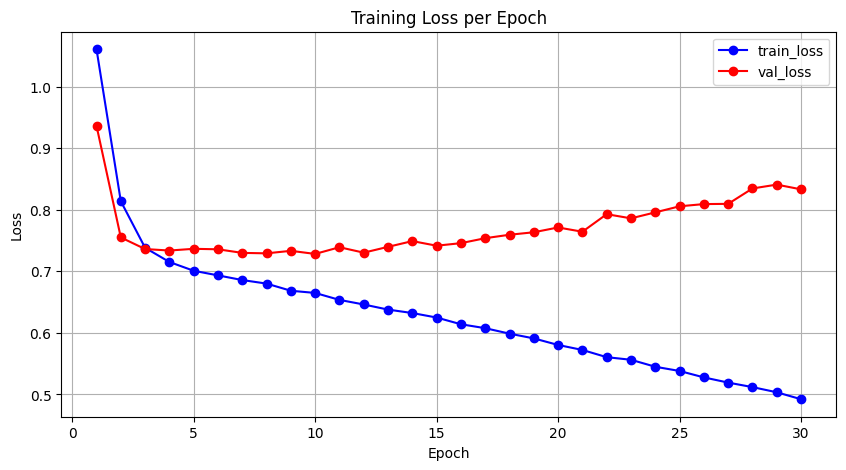

In [36]:
# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-', color='b', label = 'train_loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', linestyle='-', color='r', label = 'val_loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()